In [ ]:
#Siddiqa Bagwan
#B24CE1093

In [ ]:
!pip install tensorflow

In [ ]:
!pip install pandas
!pip install numpy

In [ ]:
import tensorflow.keras as tf

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
tf.__version__

'3.13.2'

In [ ]:
dataset=pd.read_csv('german_credit_data.csv')
dataset.tail()

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
995,no checking account,12,existing credits paid back duly till now,furniture/equipment,1736,< 100 DM,4 to < 7 years,3,female : divorced/separated/married,none,...,none,31,none,own,1,unskilled - resident,1,none,yes,good
996,< 0 DM,30,existing credits paid back duly till now,car (used),3857,< 100 DM,1 to < 4 years,4,male : divorced/separated,none,...,car,40,none,own,1,management/ self-employed/highly qualified emp...,1,"yes, registered under the customers name",yes,good
997,no checking account,12,existing credits paid back duly till now,radio/television,804,< 100 DM,>= 7 years,4,male : single,none,...,real estate,38,none,own,1,skilled employee/ official,1,none,yes,good
998,< 0 DM,45,existing credits paid back duly till now,radio/television,1845,< 100 DM,1 to < 4 years,4,male : single,none,...,savings agreement/life insurance,23,none,for free,1,skilled employee/ official,1,"yes, registered under the customers name",yes,bad
999,0 to < 200 DM,45,critical account/ other credits existing (not ...,car (used),4576,100 to < 500 DM,unemployed,3,male : single,none,...,real estate,27,none,own,1,skilled employee/ official,1,none,yes,good


In [ ]:
dataset.shape

(1000, 21)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status_account           1000 non-null   object
 1   month_duration           1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   status_savings           1000 non-null   object
 6   years_employment         1000 non-null   object
 7   payment_to_income_ratio  1000 non-null   int64 
 8   status_and_sex           1000 non-null   object
 9   secondary_obligor        1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  collateral               1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [ ]:
dataset.describe()

,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [ ]:
dataset.isna().sum()

,0
status_account,0
month_duration,0
credit_history,0
purpose,0
credit_amount,0
status_savings,0
years_employment,0
payment_to_income_ratio,0
status_and_sex,0
secondary_obligor,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in dataset.columns:
    if dataset[column].dtype == 'object':
        dataset[column] = le.fit_transform(dataset[column])


In [ ]:
y=dataset['target']
X = dataset.drop('target', axis=1)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=42,
    stratify=y
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model=Sequential()

In [ ]:
from tensorflow.keras.layers import Dropout

In [ ]:
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))




/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5938 - loss: 0.6743 - val_accuracy: 0.6687 - val_loss: 0.6244
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6375 - loss: 0.6334 - val_accuracy: 0.6750 - val_loss: 0.6070
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6953 - loss: 0.5999 - val_accuracy: 0.6750 - val_loss: 0.5982
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6875 - loss: 0.5985 - val_accuracy: 0.6812 - val_loss: 0.5914
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7047 - loss: 0.5863 - val_accuracy: 0.6750 - val_loss: 0.5823
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7000 - loss: 0.5763 - val_accuracy: 0.6812 - val_loss: 0.5744
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7328 - loss: 0.5539 - val_accuracy: 0.6812 - val_loss: 0.5691
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7063 - loss: 0.5648 - val_accuracy: 0.6687 - val_lo

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.7300000190734863


In [ ]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.73
Precision: 0.7621951219512195
Recall   : 0.8928571428571429
F1 Score : 0.8223684210526315


In [ ]:
cm = confusion_matrix(y_test, y_pred)

In [ ]:
plt.figure(figsize=(5,4))

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

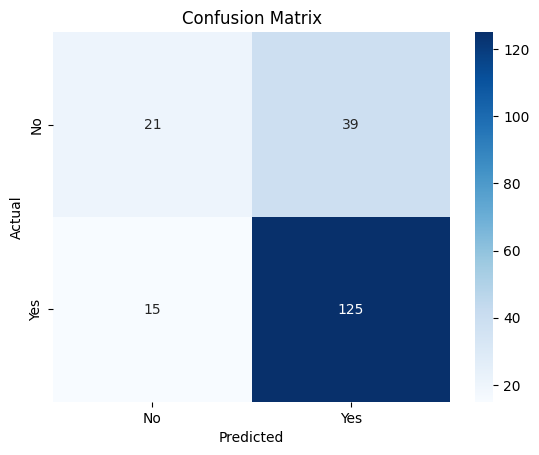

In [ ]:
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['No','Yes'],
            yticklabels=['No','Yes'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.35      0.44        60
           1       0.76      0.89      0.82       140

    accuracy                           0.73       200
   macro avg       0.67      0.62      0.63       200
weighted avg       0.71      0.73      0.71       200



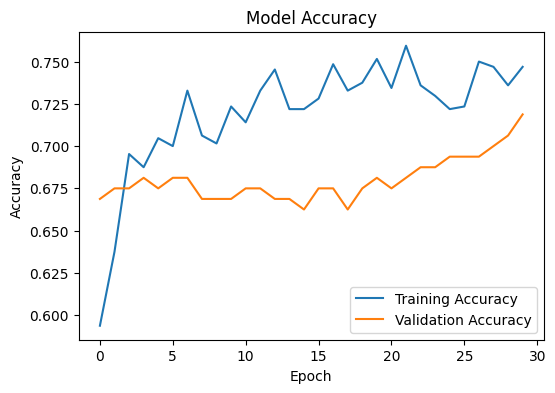

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

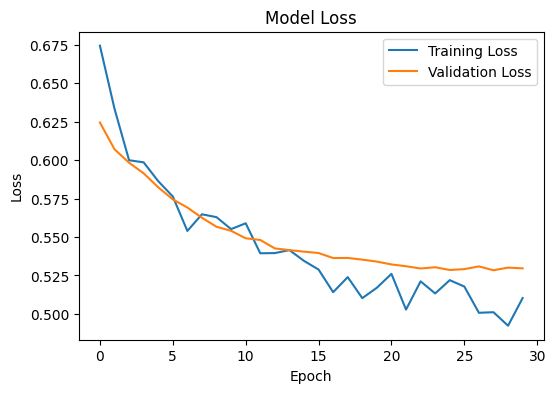

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()